# Lab Sheet 9

In [2]:
from header import *

Exercise 1

Here we simplify $x_0^2+x_1^2+x_2^2$, where $x_0=\sin(\theta)\sin(\phi)$ and $x_1=\sin(\theta)\cos(\phi)$ and $x_2=\cos(\theta)$.  (This is relevant for spherical polar coordinates.)

In [3]:
theta, phi = sp.symbols('theta phi', real=True)

x = [
 sp.sin(theta) * sp.sin(phi),
 sp.sin(theta) * sp.cos(phi),
 sp.cos(theta)
]

sp.simplify(x[0]**2 + x[1]**2 + x[2]**2)



1

Exercise 2

In [14]:
x, y, t = sp.symbols('x y t', real=True)

In [15]:
u = 8-(x-y)**2*(x+y)**2*(16-4*x**2-y**4)
u

-(x - y)**2*(x + y)**2*(-4*x**2 - y**4 + 16) + 8

In [30]:
v = u.subs({x : 2 * sp.cos(t), y : 2 * sp.sin(t)})
display(v)
display(sp.trigsimp(v))
display(sp.trigsimp(v - 8*sp.cos(8*t)))

-(-2*sin(t) + 2*cos(t))**2*(2*sin(t) + 2*cos(t))**2*(-16*sin(t)**4 - 16*cos(t)**2 + 16) + 8

8 - 16*sin(4*t)**2

0

In [31]:
del x, y, t, u, v

Exercise 3

In [6]:
x, y, z, a, b, c = sp.symbols('x y z a b c')
eqs = [
  sp.Eq(a*x + b*y + c*z, 1),  
  sp.Eq(b*x + c*y + a*z, 1),  
  sp.Eq(c*x + a*y + b*z, 1)  
]
display(Latex("Equations:"))
for eq in eqs:
    display(eq)
sol = sp.solve(eqs,[x, y, z])
display(Latex("Solution:"))
display(sol)

<IPython.core.display.Latex object>

Eq(a*x + b*y + c*z, 1)

Eq(a*z + b*x + c*y, 1)

Eq(a*y + b*z + c*x, 1)

<IPython.core.display.Latex object>

{x: 1/(a + b + c), y: 1/(a + b + c), z: 1/(a + b + c)}

In [35]:
del x, y, z, a, b, c, eqs, sol

Exercise 4

Find an approximate root for $x^4+\sin(x)=10^4$ close to $x=10$.

In [7]:
sc.optimize.root_scalar(lambda x: x**4+np.sin(x)-10**4, x0=10).root

10.000136031035714

Exercise 5

Find numerical approximations for $f(5)$, and then for $f(0),\dotsc,f(50)$, where $f(x)=(e^x+x^7)/(e^x-x^7)$

In [8]:
f = lambda x: (np.exp(x) + x**7)/(np.exp(x) - x**7)
print(f(5))
print([f(n) for n in range(51)])


-1.003806608242687
[1.0, 2.163953413738653, -1.1225271249844706, -1.0185383754323816, -1.0066870973639803, -1.003806608242687, -1.0028864528505674, -1.0026667590803273, -1.0028469097578356, -1.0033940571609772, -1.0044150178829998, -1.0061639189591798, -1.0091258262711527, -1.0142012857935216, -1.0230802015421432, -1.0390119982885597, -1.0684733803053261, -1.1250956551879607, -1.2402662528741273, -1.4989794130955643, -2.220795044726118, -6.469168971016049, 5.574474435059179, 2.074081155298447, 1.4188051469748693, 1.1852317897189424, 1.0855823585356026, 1.040109647695872, 1.018834821691931, 1.0088142586895557, 1.0041014178880834, 1.0018960266415378, 1.000870653683825, 1.0003971878104394, 1.0001800566340657, 1.0000811366472568, 1.000036354154339, 1.0000162012958154, 1.0000071833399449, 1.00000316955388, 1.0000013921016913, 1.0000006087561573, 1.0000002650982411, 1.0000001149864026, 1.0000000496868584, 1.0000000213927154, 1.0000000091788581, 1.0000000039253136, 1.0000000016733375, 1.00000

Exercise 6

Plot the curve $x^4+y^4=4$, together with the curve given by $x=(2+\sin(8t))\cos(t)$ and $y=(2+\sin(8t))\sin(t)$ (for $0\leq t\leq 2\pi$).


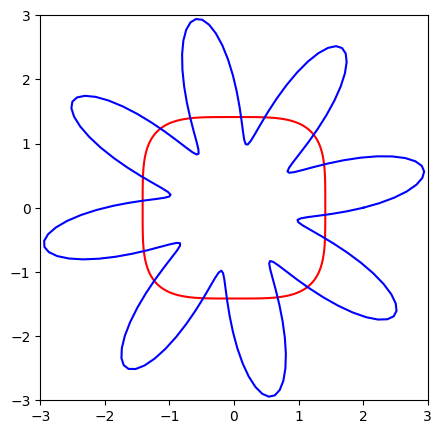

In [42]:
xs0, ys0 = np.meshgrid(np.linspace(-3,3,200),np.linspace(-3,3,200))
zs0 = xs0**4 + ys0**4
ts = np.linspace(0,2*np.pi,200)
xs1 = (2 + np.sin(8*ts)) * np.cos(ts)
ys1 = (2 + np.sin(8*ts)) * np.sin(ts)
fig, ax = plt.subplots(figsize=(5,5))
ax.contour(xs0,ys0,zs0,levels=[4],colors='red')
ax.plot(xs1, ys1, color='blue')

Exercise 7

Plot $y=\tan(\pi x)$, $y=\cot(\pi x)$, $y=-1$ and $y=1$ on the same graph, for $x$ from $-4$ to $4$.

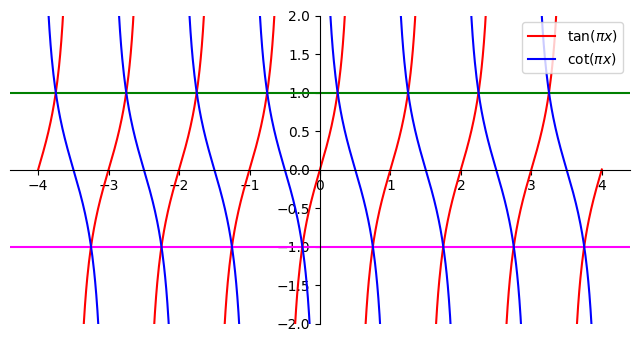

In [48]:
fig, ax = plt.subplots(figsize=(8,4))
ax.set_ylim(-2,2)
xs = np.linspace(-4,4,1000)
ys0 = np.tan(np.pi * xs)
ys1 = 1/np.tan(np.pi * xs)
ys0[np.abs(ys0) > 10] = np.nan
ys1[np.abs(ys1) > 10] = np.nan
ax.axhline( 1, color='green')
ax.axhline(-1, color='magenta')
ax.plot(xs, ys0, color='red' , label=r'$\tan(\pi x)$')
ax.plot(xs, ys1, color='blue', label=r'$\cot(\pi x)$')
fix_axes(ax)
ax.legend()

Exercise 8

Simplify some composites of Möbius functions

In [9]:
t = sp.symbols('t')

f = lambda t: ((2+sp.sqrt(3))*t-1)/(2+sp.sqrt(3)+t)
g = sp.lambdify(t, sp.simplify(f(f(f(t)))))
h = sp.lambdify(t, sp.simplify(g(g(t))))
k = sp.lambdify(t, sp.simplify(h(h(t))))
display(Latex("$f(t)=" + sp.latex(f(t)) + "$"))
display(Latex("$g(t)=f(f(f(t)))=" + sp.latex(g(t)) + "$"))
display(Latex("$h(t)=g(g(t))=" + sp.latex(h(t)) + "$"))



<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [54]:
del t, f, g, h, k

Exercise 9

Find and simplify $\displaystyle\left(\frac{1}{y}\frac{d^8y}{dx^8}\right)^{1/8}$, where $y=\sin(10x)$. 

In [56]:
x = sp.symbols('x')
y = sp.sin(10*x)
r = (sp.diff(y,x,8)/y)**sp.Rational(1,8)
sp.simplify(r)


10

In [61]:
del x, y, r

Exercise 10

Plot the curves $y=n^{3/2}x^n(1-x)^2$ for $n=1,\dotsc,10$ on the same graph, with $x$ running from $0$ to $1$.  

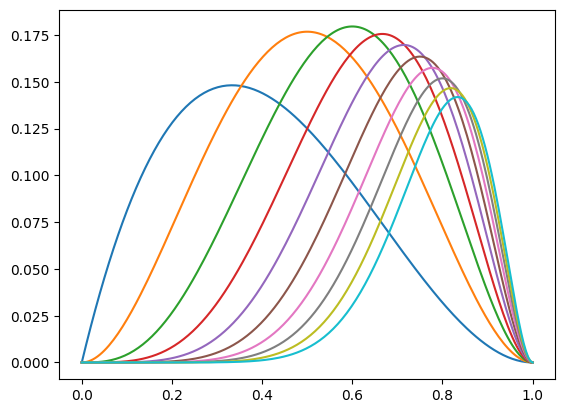

In [60]:
xs = np.linspace(0,1,200)
ns = np.arange(1,11).reshape(10,1)
ys = ns ** (3/2) * xs ** ns * (1 - xs)**2
for i in range(10):
    plt.plot(xs,ys[i])


Exercise 11

Here we investigate the function $\displaystyle y=\frac{x^4(1-x)^4}{1+x^2}$.  This is interesting because it is clear that $y\geq 0$ for $x\in[0,1]$ and the calculation below gives $\frac{22}{7}-\pi=\int_0^1 y\,dx\geq 0$ which proves that $\pi\leq\frac{22}{7}$.

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

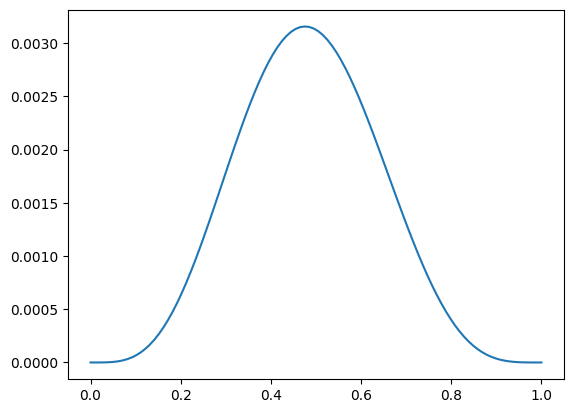

In [14]:
x = sp.symbols('x')
y = x**4*(1 - x)**4/(1+x**2)
display(Latex("$y=" + sp.latex(y) + "$"))
Y = sp.integrate(y, x)
display(Latex("$\\int y\\,dx=" + sp.latex(Y) + "$"))
Y0 = sp.integrate(y, (x,0,1))
display(Latex("$\\int_0^1 y\\,dx=" + sp.latex(Y0) + "$"))
dy = sp.factor(sp.diff(y, x))
display(Latex("$\\frac{dy}{dx}=" + sp.latex(dy) + "$"))
xs = np.linspace(0,1,100)
ys = [y.subs(x,xi) for xi in xs]
plt.plot(xs,ys)
None

In [21]:
dy_fun = sp.lambdify(x, dy, 'numpy')
x0 = sc.optimize.root_scalar(dy_fun, x0=0.5).root
y0 = y.subs(x,x0)
display(Latex(f"The hump is at $(x,y)=(" + str(x0) + "," + str(y0) + ")$"))

<IPython.core.display.Latex object>

Exercise 12

The plot below illustrates the fact that the sequence $a_n=(1+\frac{1}{n})^n/e$ tends to $1$ as $n\to\infty$.

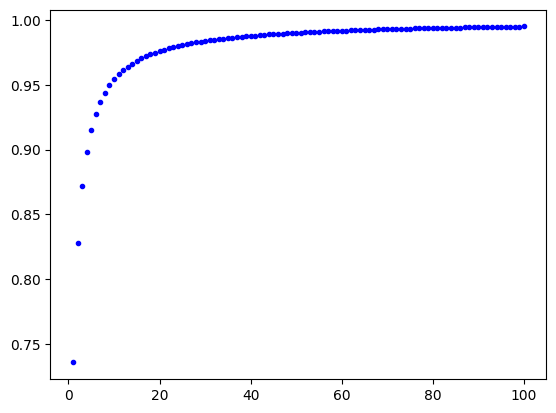

In [68]:
nn = np.arange(1,101)
aa = (1 + 1/nn) ** nn / np.exp(1)
plt.plot(nn, aa, 'b.')

We now find the first $n$ for which $a_n>0.99$.

50


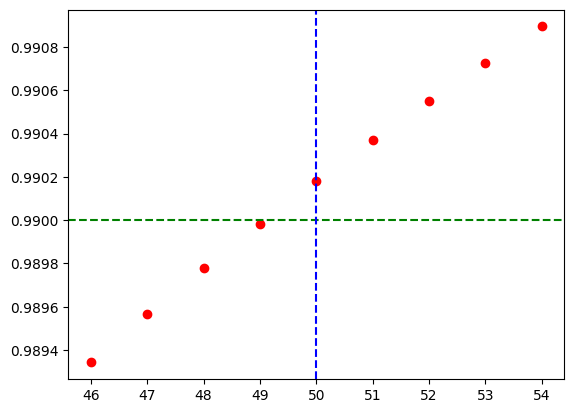

In [71]:
n0 = nn[np.argmax(aa > 0.99)]
print(n0)
nn1 = nn[((n0 - 5) < nn) & (nn < (n0 + 5))]
aa1 = aa[((n0 - 5) < nn) & (nn < (n0 + 5))]
plt.plot(nn1, aa1, 'ro')
plt.axhline(0.99, color='green', linestyle='--')
plt.axvline(n0, color='blue', linestyle='--')